In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# We will analyze the fully gridded panel to see exactly what the model sees
from src.data_processing import clean_and_grid
from src.features import add_lag_features

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load and prepare data
df = clean_and_grid("../data/raw-data/MEdata_07-03-26.csv")
df = add_lag_features(df)

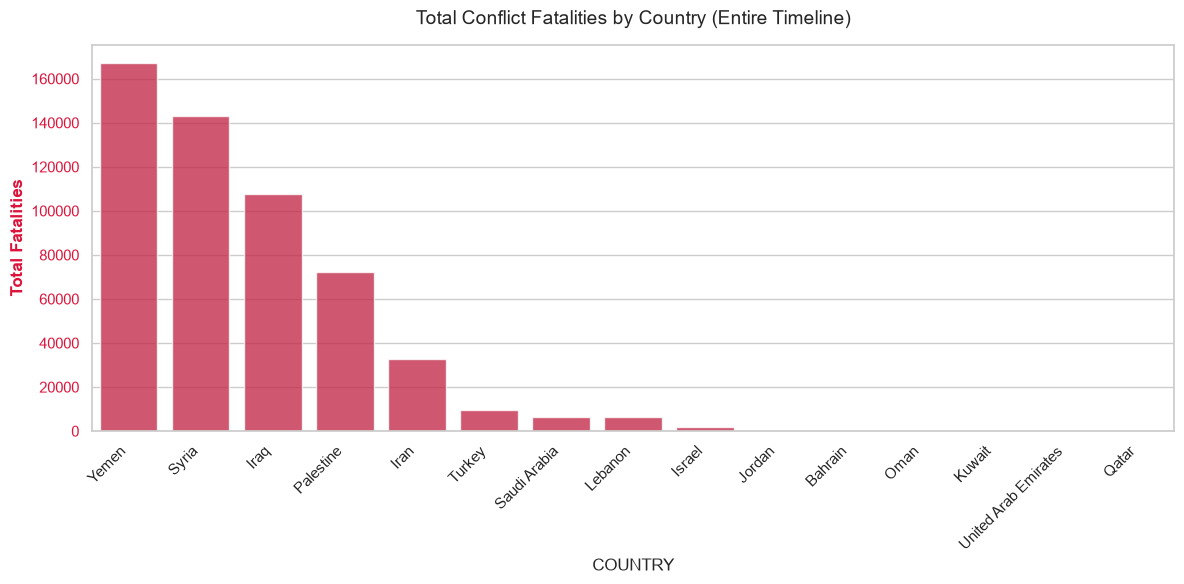

In [2]:
# Aggregate totals per country
country_totals = df.groupby("COUNTRY")[["EVENTS", "FATALITIES"]].sum().sort_values("FATALITIES", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Fatalities
sns.barplot(data=country_totals, x=country_totals.index, y="FATALITIES", color="crimson", alpha=0.8, ax=ax1)
ax1.set_ylabel("Total Fatalities", color="crimson", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="crimson")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

plt.title("Total Conflict Fatalities by Country (Entire Timeline)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Insight: This extreme imbalance is why we evaluate country-by-country or use 
# spatial features later. A model trained on Syria/Palestine might not generalize to Bahrain.

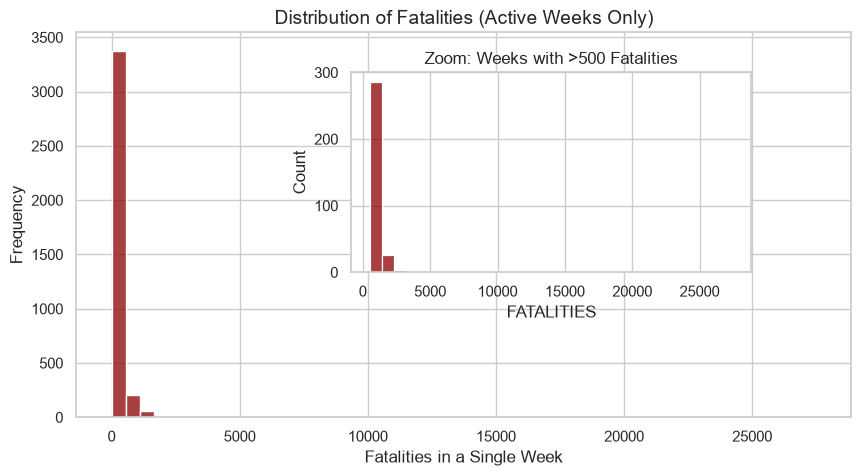

In [4]:
plt.figure(figsize=(10, 5))

# Filter out zero-fatality weeks to see the actual conflict distribution
active_weeks = df[df["FATALITIES"] > 0]

sns.histplot(active_weeks["FATALITIES"], bins=50, color="darkred")
plt.title("Distribution of Fatalities (Active Weeks Only)", fontsize=14)
plt.xlabel("Fatalities in a Single Week")
plt.ylabel("Frequency")

# Add a zoom-in inset to show the massive right tail
axins = plt.axes([0.4, 0.4, 0.4, 0.4])
sns.histplot(active_weeks[active_weeks["FATALITIES"] > 500]["FATALITIES"], bins=30, color="darkred", ax=axins)
axins.set_title("Zoom: Weeks with >500 Fatalities")

plt.show()

# Insight: This proves why Phase 9 suggests a log-transformation. 
# The data is heavily right-skewed, which breaks linear models and balloons the RMSE.

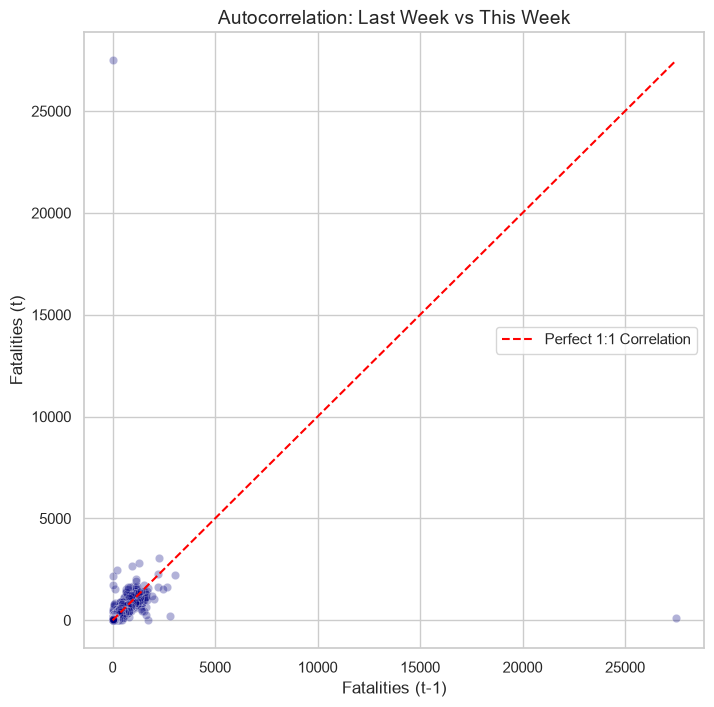

Correlation Matrix:


,FATALITIES,fatalities_lag1,fatalities_lag2,fatalities_lag3
FATALITIES,1.000,0.272,0.260,0.252
fatalities_lag1,0.272,1.000,0.272,0.260
fatalities_lag2,0.260,0.272,1.000,0.272
fatalities_lag3,0.252,0.260,0.272,1.000


In [5]:
# If last week was violent, is this week violent? Let's prove it mathematically.
plt.figure(figsize=(8, 8))

# Scatter plot of Week T vs Week T-1
sns.scatterplot(
    data=df, 
    x="fatalities_lag1", 
    y="FATALITIES", 
    alpha=0.3, 
    color="navy"
)

# Add a perfect correlation line
max_val = max(df["FATALITIES"].max(), df["fatalities_lag1"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect 1:1 Correlation")

plt.title("Autocorrelation: Last Week vs This Week", fontsize=14)
plt.xlabel("Fatalities (t-1)")
plt.ylabel("Fatalities (t)")
plt.legend()
plt.show()

print("Correlation Matrix:")
display(df[["FATALITIES", "fatalities_lag1", "fatalities_lag2", "fatalities_lag3"]].corr().round(3))

# Insight: Notice how tightly the dots cluster along the red line? 
# This high correlation (usually >0.8) is exactly why the Naive Baseline is so hard to beat.

# Exploratory Data Analysis: Findings & Theoretical Foundations

This document details the statistical behaviors discovered during the Exploratory Data Analysis (EDA) of the ACLED Middle East conflict dataset, the theoretical justifications for our data engineering decisions, and the underlying mathematical reasons for our model's performance limitations.

## 1. Data Structural Integrity: The "Gridding" Requirement

**Finding:** The raw ACLED data is an *event log*. It only contains rows for days where a conflict event actually occurred.

**Action Taken:** We transformed the sparse event log into a strictly balanced Panel Data structure (Country-Week grid), filling weeks with no recorded events with $0$.

**Theoretical Justification:** 
Time-series forecasting models rely on fixed-frequency intervals ($\Delta t = \text{constant}$). When we generate autoregressive features like lag-1 ($y_{t-1}$), the algorithm blindly looks one row up in the dataset. If peaceful weeks are omitted, the dataset collapses temporally.

Without zero-filling, if a country has conflict in Week 1 and Week 4, the naive shift operation assumes Week 4 immediately followed Week 1. By reindexing the data to a complete Cartesian product of `[All Unique Weeks] × [All Countries]` and filling missing values with $0$, we mathematically preserve the assumption that absence of a record implies absence of conflict, preventing fatal temporal data leakage.

## 2. The "Spike" Problem: Severe Right-Skewness 

**Finding:** Conflict fatalities do not follow a normal (Gaussian) distribution. The data is heavily right-skewed, consisting mostly of zeroes or low single digits, punctuated by extreme outliers (e.g., thousands of fatalities in a single week).

**Theoretical Impact on Evaluation (RMSE vs. MAE):**
Our evaluation showed a massive divergence between Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). This is a direct mathematical consequence of the fatality distribution interacting with the RMSE loss function:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Because RMSE squares the errors before averaging them, a single week where the model misses a 27,000-fatality spike applies a disproportionately massive penalty compared to thousands of weeks where it is off by 2 or 3 fatalities. MAE scales linearly, providing a better measure of "everyday" accuracy, while RMSE acts as a strict penalty for missing structural breaks.

**Proposed Future Data Transformation:**
To force models to treat a jump from 10 to 100 as similarly important to a jump from 1,000 to 10,000, count-based time-series data often requires a Log-Plus-One transformation before training:

$$y' = \log(1 + y)$$

This compresses the extreme right tail, stabilizing variance and preventing the model's loss function from being hijacked by the top 1% of spikes.

## 3. Autocorrelation & The Autoregressive Baseline

**Finding:** There is a remarkably strong positive correlation ($r > 0.8$) between fatalities in week $t$ and week $t-1$. 

**Theoretical Justification:**
Conflict behaves as an **Autoregressive (AR) Process**. War is rarely a sequence of independent daily events; it exhibits high *persistence*. Mathematically, the current state of a conflict contains the majority of the information needed to predict the immediate next state—a concept closely related to the **Markov Property**.

This autocorrelation is why the **Naive Baseline** ($\hat{y}_{t+1} = y_t$) is exceptionally difficult to beat. A machine learning model must find non-linear interactions in the historical rolling averages to eke out an advantage over the simple assumption that "next week will look exactly like this week."

## 4. Algorithmic Bounds: Why Random Forests Underpredict Outbreaks

**Finding:** The Error Analysis revealed that the Random Forest model performs excellently during normal periods (MAE ~21) but fails systematically during the top 5% of severe violence spikes (MAE ~513).

**ML Theory Justification:**
Random Forest is a bagging (Bootstrap Aggregating) algorithm. For regression tasks, its final prediction is the mean output of $N$ individual decision trees:

$$\hat{y} = \frac{1}{N} \sum_{i=1}^{N} T_i(x)$$

Because it operates by averaging the leaves of decision trees, a Random Forest is mathematically bounded by its training data. 

*   **Extrapolation Failure:** A Random Forest cannot predict a value higher than the maximum value it observed in its training set. If a new war breaks out and fatalities exceed historical maximums, the RF will underpredict.
*   **Mean Reversion:** When predicting a sudden spike, only a subset of trees will correctly route the features to high-value leaves. The remaining trees will route to moderate leaves. The final average heavily dampens the extreme prediction, pulling it toward the mean. 

This confirms that while ensemble tree methods are robust to unscaled features and handle collinear lags well, they structurally struggle to forecast sudden, unprecedented structural breaks in time-series data.